In [ ]:
import numpy as np
import torch
import torch.utils.data
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt


import config as c


# transform upper bound and lower bound
xi = np.load('./data/model1D.npy')
yi = np.load('./data/phase.npy')



c.ub = np.array([0.63, 0.79, 0.88, 0.95, 1.05, 1.2 , 1.28, 1.36, 1.36, 1.4 ])
c.lb = np.array([0.33, 0.43, 0.48, 0.51, 0.55, 0.6 , 0.58, 0.56, 0.56, 0.6 ])

xi = 4*(xi-(c.ub+c.lb)/2)/(c.ub-c.lb)

train_size = 100000
test_size = 10000

x_train = torch.Tensor(xi[:train_size,:])
y_train = torch.Tensor(yi[:train_size,:])
x_test = torch.Tensor(xi[-test_size:,:])
y_test = torch.Tensor(yi[-test_size:,:])





#--------basic setting------
c.filename_out = './models/GI-INO_model.pt'
c.device = 'cuda:0'

#--------Adam setting-------
c.lr_init         = 1e-3
c.final_decay = 0.005
c.batch_size = 500
c.n_its_per_epoch = 20
c.n_epochs = 1000
c.pre_low_lr = 0

#-------model setting-------
c.ndim_x = 10
c.ndim_pad_x = 12
c.ndim_y = 14
c.ndim_z = 22
c.ndim_pad_zy = 0
c.mmd_back_weighted = False
c.add_pad_noise = 1e-1
c.add_y_noise = 1e-2
c.add_z_noise = 5e-1
c.hidden_layer_sizes = 256
c.cnn_layer_sizes = 32
c.use_permutation = True
c.interactive_visualization = False
c.init_scale = 0.001
c.N_blocks=4 

##-------loss setting---------
c.interactive_visualization = False
c.show_test_loss = True
c.show_total_loss = False



c.train_max_likelihood = True
c.train_forward_fit       = True
c.train_independence_loss = True

c.lambd_mmd_forw       = 2.
c.lambd_mmd_back       = 2

c.lambd_reconstruct    = 1.

c.lambd_max_likelihood = 0.1
c.lambd_fit_forw       = 10
c.lambd_fit_back       = 0.1
c.lambd_independence_loss    = 0.1
c.lambd_similarity_loss = 0.1


c.train_loader = torch.utils.data.DataLoader(TensorDataset(x_train,y_train[:,None]),batch_size=c.batch_size,shuffle=True,drop_last=True)
c.test_loader = torch.utils.data.DataLoader(TensorDataset(x_test,y_test[:,None]),batch_size=c.batch_size,shuffle=False,drop_last=True)

import train

print('all done before train')

all done before train


In [ ]:
import os
import model

# if os.path.exists(c.filename_out):
#         model.load(c.filename_out)
train.main()

Config options:

  N_blocks                 	4
  adam_betas               	(0.9, 0.95)
  add_pad_noise            	0.1
  add_y_noise              	0.01
  add_z_noise              	0.5
  batch_size               	500
  cnn_layer_sizes          	32
  device                   	cuda:0
  exponent_clamping        	4.0
  filename_in              	
  filename_out             	./models/INNs_1D_ind_prior_normal_100k.pt
  final_decay              	0.005
  hidden_layer_sizes       	256
  init_scale               	0.001
  interactive_visualization	False
  kde                      	[]
  l2_weight_reg            	1e-05
  lambd_fit_back           	0.1
  lambd_fit_forw           	10
  lambd_independence_loss  	0.1
  lambd_max_likelihood     	0.1
  lambd_mmd_back           	2
  lambd_mmd_forw           	2.0
  lambd_reconstruct        	1.0
  lambd_similarity_loss    	0.1
  lb                       	[0.33 0.43 0.48 0.51 0.55 0.6  0.58 0.56 0.56 0.6 ]
  lr_init                  	0.001
  mi_save_path       

## Test

In [2]:
import torch.nn as nn
from FrEIA.framework import *
from FrEIA.modules import *

########################### Load Pre-trained Model ###########################
nodes = [InputNode(c.ndim_x + c.ndim_y + c.ndim_pad_x, name='input')]

def subnet_fc(c_in, c_out):
    return nn.Sequential(nn.Linear(c_in, c.hidden_layer_sizes), nn.ReLU(),
                         nn.Linear(c.hidden_layer_sizes,  c_out))

for i in range(c.N_blocks):
    nodes.append(Node(nodes[-1].out0,
                  GLOWCouplingBlock,
                  {'subnet_constructor':subnet_fc, 'clamp':c.exponent_clamping},
                  name='coupling_{}'.format(i)))
    
    if c.use_permutation:
        nodes.append(Node(nodes[-1].out0,
                      PermuteRandom,
                      {'seed':i}, name='permute_{}'.format(i)))

nodes.append(OutputNode([nodes[-1].out0], name='output'))

INN = ReversibleGraphNet(nodes, verbose=c.verbose_construction)
INN.to(c.device)

state_dicts = torch.load(c.filename_out)
INN.load_state_dict(state_dicts['net'])

C:\Users\ywz21\AppData\Local\Temp\ipykernel_11120\3314756166.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dicts = torch.load(c.filename_out)


<All keys matched successfully>

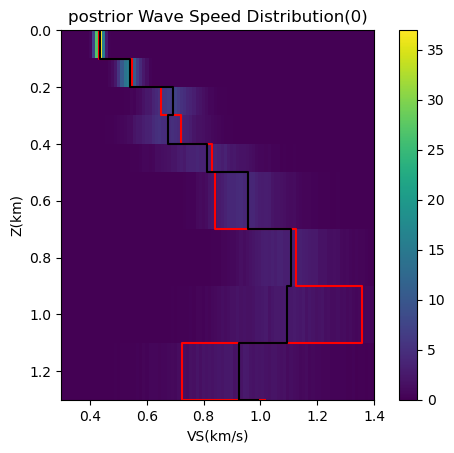

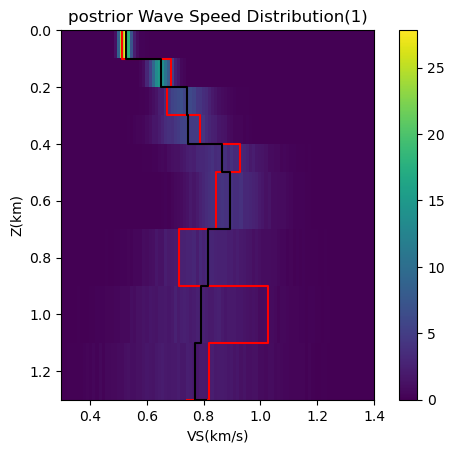

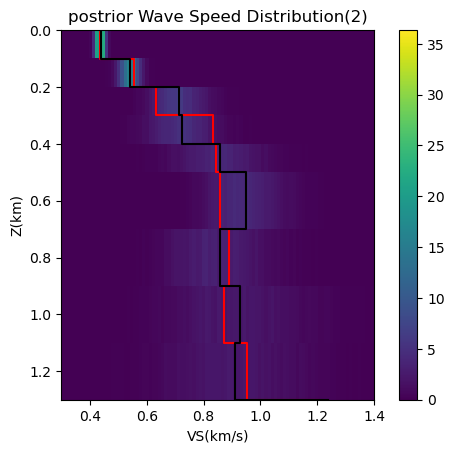

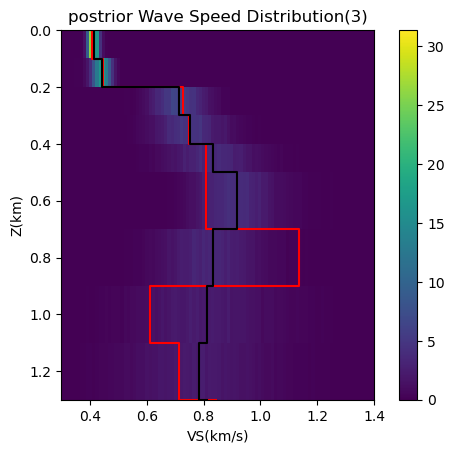

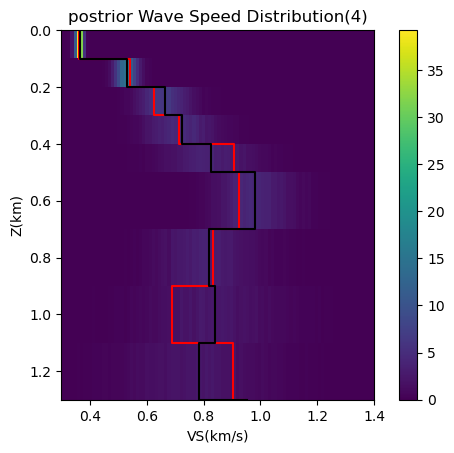

In [ ]:

N_test=5000 #批量

for k in range(5):

    x0_test = xi[-k,:]

    y0_test= yi[-k,:]

    x_test= np.tile(x0_test, (N_test, 1))
    y_test= np.tile(y0_test, (N_test, 1))
    x_test=torch.Tensor(x_test).to(c.device)
    y_test=torch.Tensor(y_test).to(c.device)


    def noise_batch(N, ndim):
        return torch.randn(N, ndim).to(c.device)

    noise_test = c.add_y_noise * noise_batch(N_test, c.ndim_y)

    if c.add_y_noise > 0:
        y_test += noise_test

    x_test = torch.cat((x_test, noise_test), dim=1)
    if c.ndim_pad_x:
        x_test = torch.cat((x_test, c.add_pad_noise * noise_batch(N_test, c.ndim_pad_x)), dim=1)
    if c.ndim_pad_zy:
        y_test = torch.cat((c.add_pad_noise * noise_batch(N_test, c.ndim_pad_zy), y_test), dim=1)
    y_test = torch.cat((noise_batch(N_test, c.ndim_z), y_test), dim=1)

    zy_pred = INN(x_test)[0]
    x_noise_pred = INN(y_test, rev=True)[0]

    z_pred, y_pred = zy_pred[:, 0:c.ndim_z], zy_pred[:, c.ndim_z:(c.ndim_z+c.ndim_y)]
    x_pred, noise_pred = x_noise_pred[:, 0:c.ndim_x], x_noise_pred[:, c.ndim_x:(c.ndim_x+c.ndim_y)]

   
    x_sampled =  x_pred.cpu().detach().numpy()*(c.ub-c.lb)/4 +(c.ub+c.lb)/2
    x_sampled_average=np.mean(x_sampled, axis=0)
    x0_sampled = x0_test*(c.ub-c.lb)/4 +(c.ub+c.lb)/2


    bin_widths = np.array([0.1] * 5 + [0.2] * 4)
    bin_edges = np.concatenate(([0], np.cumsum(bin_widths)))

    depths = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9, 1.1, 1.3])


    x_sampled_extended = np.hstack((
        x_sampled[:, :5],  # 前五层，每层0.1km
        np.repeat(x_sampled[:, 5:], 2, axis=1)  
    ))


    depths_extended = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3])

    bins = 100


    H = np.zeros((len(depths_extended) - 1, bins))  # 50个bins


    for i in range(len(depths_extended) - 1):
        hist, _ = np.histogram(x_sampled_extended[:, i], bins=bins, range=(0.3, 1.4), density=True)
        H[i, :] = hist


    fig, ax = plt.subplots()



    extent = [0.3, 1.4, depths_extended[0], depths_extended[-1]]
    im = ax.imshow(H, aspect='equal', extent=extent, interpolation='nearest', origin='lower')


    # ax.plot(sample_wave_speeds, depths, marker='o', color='red', label='Sample Wave Speed')
    ax.step(x0_sampled, depths, where='pre', color='red', label='Sample Wave Speed')#样本值

    ax.step(x_sampled_average, depths, where='pre', color='black', label='Sample Wave Speed')#反演均值


    ax.set_ylim(ax.get_ylim()[::-1])


    ax.set_xlabel('VS(km/s)')
    ax.set_ylabel('Z(km)')
    ax.set_title(f'postrior Wave Speed Distribution({k})')


    plt.colorbar(im, ax=ax)

    plt.show()

#     #######################################
#     phase_pred = solve_equations(x_sampled_average.astype(np.float64),transform=False)
#     phase0 = solve_equations(x0_sampled,transform=False)
#     print('resimulate_error:',np.sum((phase_pred-phase0)**2)/np.sum((phase0)**2))
#     #######################################


# print('save fig')
# # plt.savefig("./flow_sample.pdf",
# #             pad_inches=0.2, bbox_inches='tight')
# filename = f"./figures/Indloss_sample{k}.png"  
# fig.savefig(filename)  

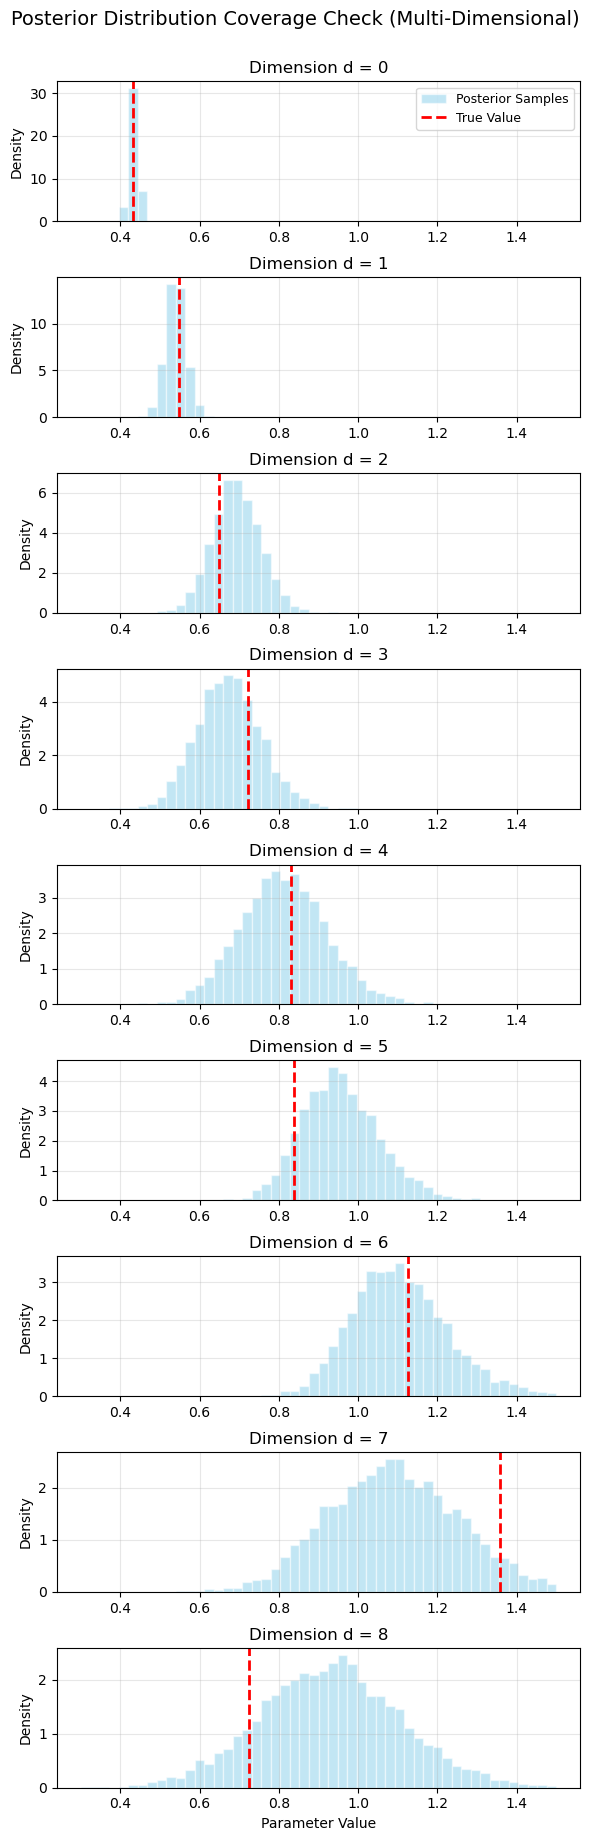

In [7]:
import numpy as np
import matplotlib.pyplot as plt


k=0

x0_test = xi[-k,:]

y0_test= yi[-k,:]


y_test= np.tile(y0_test, (N_test, 1))

y_test=torch.Tensor(y_test).to(c.device)

def noise_batch(N, ndim):
    return torch.randn(N, ndim).to(c.device)

noise_test = c.add_y_noise * noise_batch(N_test, c.ndim_y)

if c.add_y_noise > 0:
    y_test += noise_test

if c.ndim_pad_zy:
    y_test = torch.cat((c.add_pad_noise * noise_batch(N_test, c.ndim_pad_zy), y_test), dim=1)
y_test = torch.cat((noise_batch(N_test, c.ndim_z), y_test), dim=1)
# y_test = torch.cat((c.add_z_noise*noise_batch(N_test, c.ndim_z), y_test), dim=1)

x_noise_pred = INN(y_test, rev=True)[0]

x_pred, noise_pred = x_noise_pred[:, 0:c.ndim_x], x_noise_pred[:, c.ndim_x:(c.ndim_x+c.ndim_y)]

x_sampled =  x_pred.cpu().detach().numpy()*(c.ub-c.lb)/4 +(c.ub+c.lb)/2
x_sampled_average=np.mean(x_sampled, axis=0)
x0_sampled = x0_test*(c.ub-c.lb)/4 +(c.ub+c.lb)/2

x_sampled = x_sampled
x0_sampled = x0_sampled

ub = np.array([0.63, 0.79, 0.88, 0.95, 1.05, 1.2 , 1.28, 1.36, 1.36, 1.4 ])
lb = np.array([0.33, 0.43, 0.48, 0.51, 0.55, 0.6 , 0.58, 0.56, 0.56, 0.6 ])


d_values = [0,1, 2,3,4,5,6, 7,8]

fig, axes = plt.subplots(nrows=len(d_values), ncols=1, figsize=(6, 2*len(d_values)))


for idx, (d, ax) in enumerate(zip(d_values, axes)):

    posterior_samples = x_sampled[:, d]
    true_value = x0_sampled[d]
    

    ax.hist(posterior_samples,
            range=(0.3,1.5),
            bins=50,
            density=True,
            alpha=0.5,
            color='skyblue',
            edgecolor='white',
            label='Posterior Samples')
    

    ax.axvline(x=true_value,
              color='red',
              linestyle='--',
              linewidth=2,
              label='True Value')
    

    ax.set_title(f'Dimension d = {d}', fontsize=12)
    ax.set_ylabel('Density', fontsize=10)
    ax.grid(alpha=0.3)
    

    if idx == len(d_values)-1:
        ax.set_xlabel('Parameter Value', fontsize=10)
    

    if idx == 0:
        ax.legend(loc='upper right', fontsize=9)


plt.tight_layout()
plt.subplots_adjust(hspace=0.4)  
fig.suptitle('Posterior Distribution Coverage Check (Multi-Dimensional)', 
            y=1.02, fontsize=14)  

plt.show()